# Segmentez des clients d'un site e-commerce

Nous devons fournir aux équipes e-commerce d’Olist une segmentation des clients qu’elles pourront utiliser au quotidien pour leurs campagnes de communication.

Nous devons comprendre les différents types d’utilisateurs à partir de leur comportement et de leurs données personnelles.

Nous devons remettre à l’équipe Marketing une description exploitable de cette segmentation ainsi que la logique sous-jacente afin d’en assurer une utilisation optimale.

Enfin, nous devons proposer un contrat de maintenance fondé sur une analyse de la stabilité des segments dans le temps.

## Import des librairies

In [21]:
import pandas as pd 
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.metrics import adjusted_rand_score
from scipy.stats import ks_2samp
from kneed import KneeLocator
import sqlite3

## Les données 

In [4]:
df = pd.read_csv("rfmeighteenmonth.csv")
dfo = pd.read_csv("rfmplusoneweek.csv")
dftwo = pd.read_csv("rfmplustwoweek.csv")
dfthree = pd.read_csv("rfmplusthreeweek.csv")
dffour = pd.read_csv("rfmplusfourweek.csv")
dffive = pd.read_csv("rfmplusfiveweek.csv")

## Kmean et Stabilité des clusters 

### Suppression des dates

In [6]:
# Crée un nouveau DataFrame sans la colonne 'last_purchase_date'
df_sans_date = df.drop(columns=['last_purchase_date'])
df_sans_date

,customer_unique_id,recency_days,frequency,monetary_value
0,0000f46a3911fa3c0805444483337064,358.121493,1,69.00
1,0000f6ccb0745a6a4b88665a16c9f078,142.146053,1,25.99
2,0004aac84e0df4da2b147fca70cf8255,109.176597,1,180.00
3,00053a61a98854899e70ed204dd4bafe,3.530775,1,382.00
4,0005e1862207bf6ccc02e4228effd9a0,364.019306,1,135.00
...,...,...,...,...
56226,fffbf87b7a1a6fa8b03f081c5f51a201,66.057859,1,149.00
56227,fffcf5a5ff07b0908bd4e2dbc735a684,268.124583,1,1570.00
56228,fffea47cd6d3cc0a88bd621562a9d061,83.161157,1,64.89
56229,ffff371b4d645b6ecea244b27531430a,389.340787,1,89.90


### Normalisation

In [8]:
# 1. On sélectionne UNIQUEMENT les colonnes numériques (RFM) pour la normalisation
features_to_scale = df_sans_date[['recency_days', 'frequency', 'monetary_value']]

# 2. On normalise ce nouveau DataFrame qui ne contient que des nombres
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features_to_scale)

print("DataFrame RFM créé et normalisé. Prêt pour l'étape suivante.")

DataFrame RFM créé et normalisé. Prêt pour l'étape suivante.


### Trouver le nombre optimal de cluster (K)

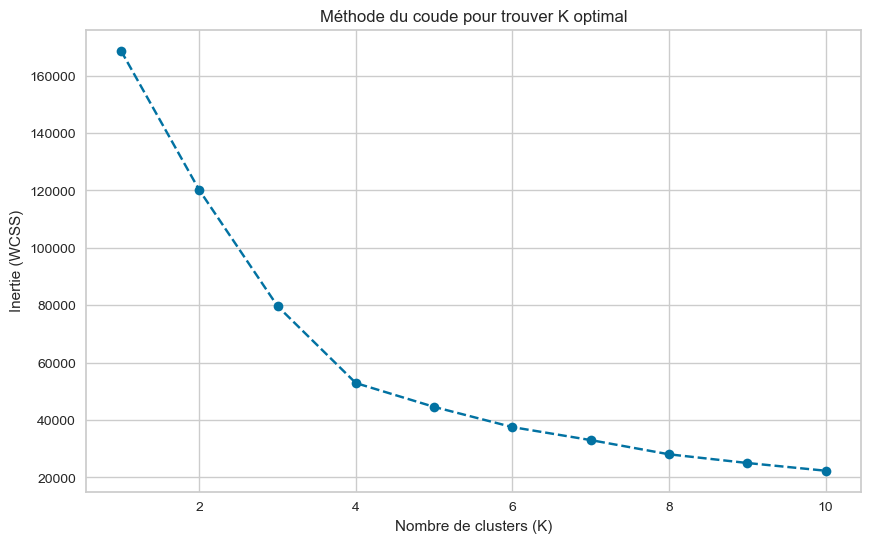

In [10]:

# On utilise les données RFM normalisées créées à l'étape précédente
# La variable s'appelle 'rfm_scaled'

# 1. Initialiser une liste vide pour stocker l'inertie de chaque modèle
wcss = [] 
k_range = range(1, 11) # On va tester de 1 à 10 clusters

# 2. Créer une boucle pour entraîner un modèle pour chaque valeur de K
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_) # L'inertie mesure la compacité des clusters

# 3. Créer le graphique pour visualiser le "coude"
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Méthode du coude pour trouver K optimal')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie (WCSS)')
plt.grid(True)
plt.show()

### Trouver K automatiquement

Le coude optimal a été trouvé de manière programmatique à K = 4


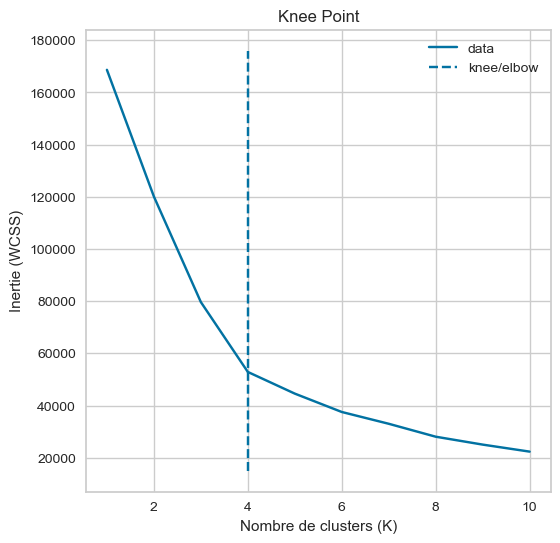

In [11]:
# On utilise les résultats de la méthode du coude
# wcss : la liste des inerties
# k_range : la liste des K testés (range(1, 11))

# On instancie KneeLocator
# curve='convex' car la courbe est convexe
# direction='decreasing' car l'inertie diminue
knee_locator = KneeLocator(
    x=k_range, 
    y=wcss, 
    curve='convex', 
    direction='decreasing'
)

# La bibliothèque trouve le coude pour nous
optimal_k_programmatic = knee_locator.elbow

print(f"Le coude optimal a été trouvé de manière programmatique à K = {optimal_k_programmatic}")

# (Optionnel) Visualiser le résultat sur le graphique
knee_locator.plot_knee()
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie (WCSS)")
plt.show()

### Entrainement du modele

In [43]:
# On crée un DataFrame propre pour l'analyse RFM
rfm_df = df_sans_date[['recency_days', 'frequency', 'monetary_value']].copy()

# On définit le K optimal
OPTIMAL_K = optimal_k_programmatic # ou mettez 4 si vous préférez

# On entraîne le modèle K-Means final
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)

# On ajoute le numéro de cluster à notre DataFrame RFM
rfm_df['cluster'] = clusters

print(f"Modèle entraîné avec K={OPTIMAL_K}. Les segments ont été ajoutés au DataFrame.")
print("\nAperçu du résultat :")
print(rfm_df.head())

Modèle entraîné avec K=4. Les segments ont été ajoutés au DataFrame.

Aperçu du résultat :
   recency_days  frequency  monetary_value  cluster
0    358.121493          1           69.00        1
1    142.146053          1           25.99        0
2    109.176597          1          180.00        0
3      3.530775          1          382.00        0
4    364.019306          1          135.00        1


### Visualisation

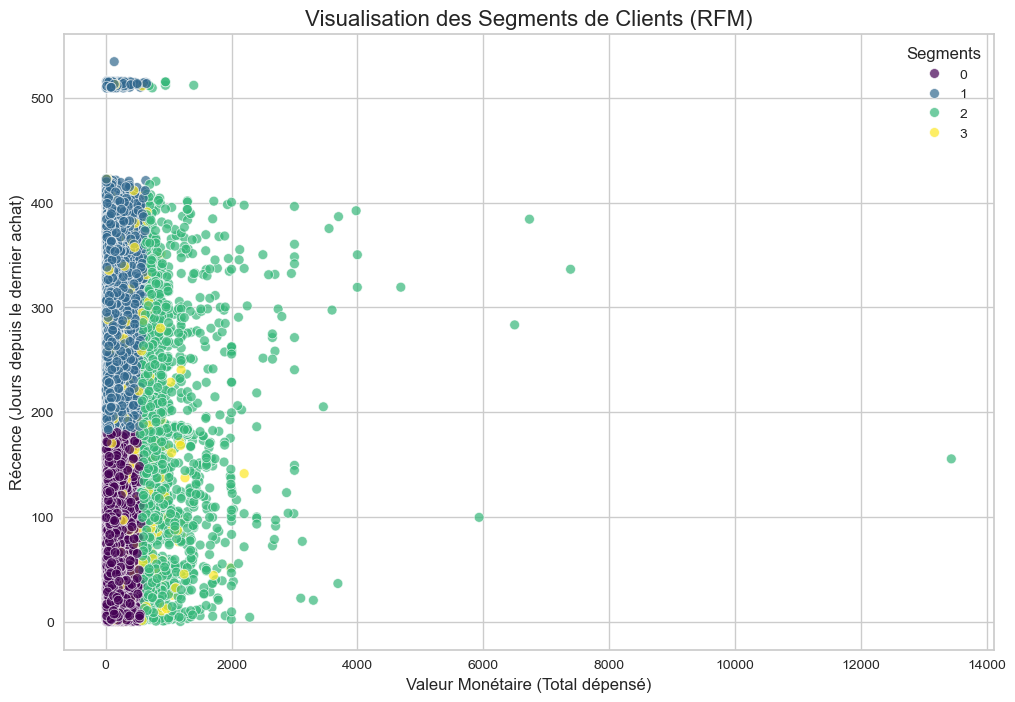

In [46]:
# On crée le graphique
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=rfm_df, 
    x='monetary_value', 
    y='recency_days', 
    hue='cluster',      # La couleur des points est déterminée par le segment
    palette='viridis',  # Choix de la palette de couleurs
    s=50,               # Taille des points
    alpha=0.7           # Transparence
)

plt.title('Visualisation des Segments de Clients (RFM)', fontsize=16)
plt.xlabel('Valeur Monétaire (Total dépensé)', fontsize=12)
plt.ylabel('Récence (Jours depuis le dernier achat)', fontsize=12)
plt.legend(title='Segments')
plt.grid(True)
plt.show()

### Stabilité des clusters

In [19]:
# On utilise les données RFM normalisées (rfm_scaled)
X = rfm_scaled
OPTIMAL_K = 4

# On va stocker les résultats de 5 lancements différents
clustering_results = []

print("Lancement de 5 exécutions de K-Means avec des initialisations différentes...")
for i in range(5):
    # On force une initialisation différente à chaque fois avec un nouveau random_state
    # n_init=1 pour s'assurer qu'il ne fait qu'un seul essai à chaque fois
    kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    labels = kmeans.fit_predict(X)
    clustering_results.append(labels)
    print(f"Exécution {i+1} terminée.")

# --- Comparaison des résultats avec l'ARI ---
print("\n--- Comparaison de la stabilité des clusters (Score ARI) ---")
# On compare chaque résultat avec le premier (notre référence)
for i in range(1, len(clustering_results)):
    score = adjusted_rand_score(clustering_results[0], clustering_results[i])
    print(f"Similarité entre l'exécution 1 et l'exécution {i+1} : {score:.4f}")

Lancement de 5 exécutions de K-Means avec des initialisations différentes...
Exécution 1 terminée.
Exécution 2 terminée.
Exécution 3 terminée.
Exécution 4 terminée.
Exécution 5 terminée.

--- Comparaison de la stabilité des clusters (Score ARI) ---
Similarité entre l'exécution 1 et l'exécution 2 : 0.9997
Similarité entre l'exécution 1 et l'exécution 3 : 0.9982
Similarité entre l'exécution 1 et l'exécution 4 : 0.9978
Similarité entre l'exécution 1 et l'exécution 5 : 0.9997


## Simulation ARI 

### Création des dataframes

In [25]:
# ==============================================================================
# ÉTAPE 1 : Configuration
# ==============================================================================

DB_NAME = "olist.db"
ITERATIONS = 14  

base_sql_query = """
-- On calcule la date de fin de la période d'analyse
WITH period_end AS (
    SELECT
        DATE(MIN(order_purchase_timestamp), {time_modifier}) AS end_date
    FROM orders
)
-- On calcule les valeurs RFM pour les clients actifs durant cette période
SELECT
    c.customer_unique_id,
    MAX(o.order_purchase_timestamp) AS last_purchase_date,
    JULIANDAY((SELECT end_date FROM period_end)) - JULIANDAY(MAX(o.order_purchase_timestamp)) AS recency_days,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(oi.price) AS monetary_value
FROM
    orders AS o
INNER JOIN
    order_items AS oi ON o.order_id = oi.order_id
INNER JOIN
    customers AS c ON o.customer_id = c.customer_id
WHERE
    o.order_status = 'delivered'
    AND o.order_purchase_timestamp < (SELECT end_date FROM period_end)
GROUP BY
    c.customer_unique_id;
"""

# ==============================================================================
# ÉTAPE 2 : Boucle d'automatisation
# ==============================================================================

try:
    # Se connecter à la base de données
    conn = sqlite3.connect(DB_NAME)
    print(f"Connecté à la base de données '{DB_NAME}'.")

    # On boucle pour chaque période (18m, 18m + 2s, 18m + 4s, etc.)
    for i in range(ITERATIONS):
        
        # Calculer le nombre de semaines et de jours à ajouter
        weeks_to_add = i * 2
        days_to_add = weeks_to_add * 7
        
        # --- Créer le modificateur de temps et le nom du fichier ---
        if weeks_to_add == 0:
            # Cas de base : 18 mois
            time_modifier = "'+18 months'"
            filename = "rfm_18m.csv"
        else:
            # Cas suivants : 18 mois + X jours
            time_modifier = f"'+18 months', '+{days_to_add} days'"
            filename = f"rfm_18m_plus_{weeks_to_add}w.csv"
            
        print(f"Génération du fichier '{filename}'...")
        
        # --- Exécuter la requête et sauvegarder le résultat ---
        
        # On remplace le placeholder dans la requête avec notre modificateur de temps
        final_query = base_sql_query.format(time_modifier=time_modifier)
        
        # On exécute la requête et on charge le résultat dans un DataFrame
        df = pd.read_sql_query(final_query, conn)
        
        # On sauvegarde le DataFrame en fichier CSV
        df.to_csv(filename, index=False)
        
    print("\nAutomatisation terminée avec succès !")

except Exception as e:
    print(f"Une erreur est survenue : {e}")

finally:
    # S'assurer que la connexion est bien fermée, même en cas d'erreur
    if 'conn' in locals() and conn:
        conn.close()
        print("Connexion à la base de données fermée.")

Connecté à la base de données 'olist.db'.
Génération du fichier 'rfm_18m.csv'...
Génération du fichier 'rfm_18m_plus_2w.csv'...
Génération du fichier 'rfm_18m_plus_4w.csv'...
Génération du fichier 'rfm_18m_plus_6w.csv'...
Génération du fichier 'rfm_18m_plus_8w.csv'...
Génération du fichier 'rfm_18m_plus_10w.csv'...
Génération du fichier 'rfm_18m_plus_12w.csv'...
Génération du fichier 'rfm_18m_plus_14w.csv'...
Génération du fichier 'rfm_18m_plus_16w.csv'...
Génération du fichier 'rfm_18m_plus_18w.csv'...
Génération du fichier 'rfm_18m_plus_20w.csv'...
Génération du fichier 'rfm_18m_plus_22w.csv'...
Génération du fichier 'rfm_18m_plus_24w.csv'...
Génération du fichier 'rfm_18m_plus_26w.csv'...

Automatisation terminée avec succès !
Connexion à la base de données fermée.


### Maintenance 

--- Étape 1 : Chargement des fichiers CSV ---
- Fichier 'rfm_18m.csv' chargé.
- Fichier 'rfm_18m_plus_2w.csv' chargé.
- Fichier 'rfm_18m_plus_4w.csv' chargé.
- Fichier 'rfm_18m_plus_6w.csv' chargé.
- Fichier 'rfm_18m_plus_8w.csv' chargé.
- Fichier 'rfm_18m_plus_10w.csv' chargé.
- Fichier 'rfm_18m_plus_12w.csv' chargé.
- Fichier 'rfm_18m_plus_14w.csv' chargé.
- Fichier 'rfm_18m_plus_16w.csv' chargé.
- Fichier 'rfm_18m_plus_18w.csv' chargé.
- Fichier 'rfm_18m_plus_20w.csv' chargé.
- Fichier 'rfm_18m_plus_22w.csv' chargé.
- Fichier 'rfm_18m_plus_24w.csv' chargé.
- Fichier 'rfm_18m_plus_26w.csv' chargé.
Chargement terminé.

--- Étape 2 : Entraînement des modèles idéaux pour chaque période ---
- Traitement de la période : 18m
- Traitement de la période : 18m + 2w
- Traitement de la période : 18m + 4w
- Traitement de la période : 18m + 6w
- Traitement de la période : 18m + 8w
- Traitement de la période : 18m + 10w
- Traitement de la période : 18m + 12w
- Traitement de la période : 18m + 14w


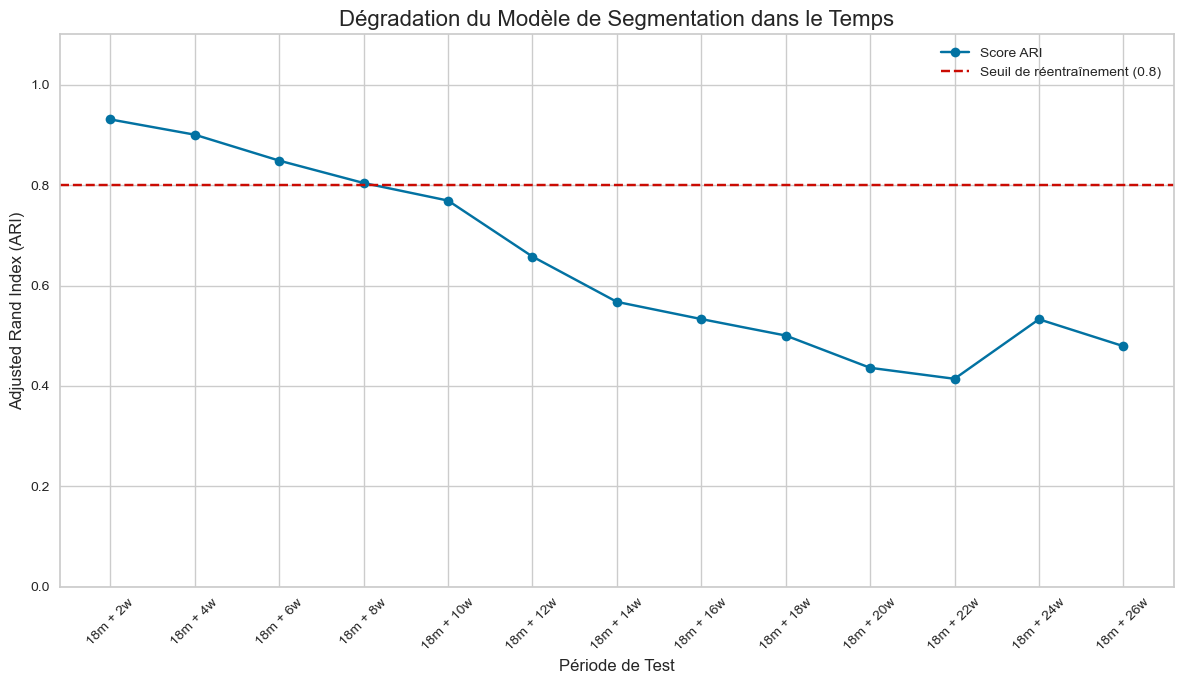

In [28]:
# ==============================================================================
# ÉTAPE 1 : Chargement Automatique des Fichiers CSV
# ==============================================================================

# Dictionnaire associant les périodes aux noms des fichiers CSV
csv_files = {
    "18m": "rfm_18m.csv",
    "18m + 2w": "rfm_18m_plus_2w.csv",
    "18m + 4w": "rfm_18m_plus_4w.csv",
    "18m + 6w": "rfm_18m_plus_6w.csv",
    "18m + 8w": "rfm_18m_plus_8w.csv",
    "18m + 10w": "rfm_18m_plus_10w.csv",
    "18m + 12w": "rfm_18m_plus_12w.csv",
    "18m + 14w": "rfm_18m_plus_14w.csv",
    "18m + 16w": "rfm_18m_plus_16w.csv",
    "18m + 18w": "rfm_18m_plus_18w.csv",
    "18m + 20w": "rfm_18m_plus_20w.csv",
    "18m + 22w": "rfm_18m_plus_22w.csv",
    "18m + 24w": "rfm_18m_plus_24w.csv",
    "18m + 26w": "rfm_18m_plus_26w.csv"
}

dataframes_a_tester = {}
print("--- Étape 1 : Chargement des fichiers CSV ---")
for periode, filename in csv_files.items():
    try:
        dataframes_a_tester[periode] = pd.read_csv(filename)
        print(f"- Fichier '{filename}' chargé.")
    except FileNotFoundError:
        print(f"ERREUR: Le fichier '{filename}' n'a pas été trouvé. Veuillez vérifier le nom ou le chemin d'accès.")
print("Chargement terminé.\n")


# ==============================================================================
# ÉTAPE 2 : Entraînement des Modèles "Idéaux" pour Chaque Période
# ==============================================================================

resultats_clustering = {}
modeles_entraines = {}

print("--- Étape 2 : Entraînement des modèles idéaux pour chaque période ---")
for periode, df_temp in dataframes_a_tester.items():
    print(f"- Traitement de la période : {periode}")
    
    # Préparation des données
    features = df_temp[['recency_days', 'frequency', 'monetary_value']]
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    
    # Recherche du K optimal
    wcss = [KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(scaled_features).inertia_ for k in range(1, 11)]
    knee_locator = KneeLocator(x=range(1, 11), y=wcss, curve='convex', direction='decreasing')
    optimal_k = knee_locator.elbow if knee_locator.elbow else 4
    
    # Entraînement du modèle final
    final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
    df_temp['cluster'] = final_kmeans.fit_predict(scaled_features)
    
    # Stockage des résultats
    resultats_clustering[periode] = df_temp
    modeles_entraines[periode] = final_kmeans

print("Entraînement des modèles terminé.\n")


# ==============================================================================
# ÉTAPE 3 : Simulation de la Dégradation et Calcul des Scores ARI
# ==============================================================================

reference_periode = "18m"
reference_model = modeles_entraines[reference_periode]
reference_df = resultats_clustering[reference_periode]

# Création d'un scaler basé uniquement sur les données de référence
reference_scaler = StandardScaler()
reference_scaler.fit(reference_df[['recency_days', 'frequency', 'monetary_value']])

ari_scores = []

print("--- Étape 3 : Simulation de la dégradation du modèle de référence ---")
for periode, current_df in resultats_clustering.items():
    if periode == reference_periode:
        continue

    # Obtenir les clusters "vrais" (idéaux) pour la période
    true_labels = current_df['cluster']

    # Préparer les données de la période pour la prédiction
    features_to_predict = current_df[['recency_days', 'frequency', 'monetary_value']]
    scaled_features_to_predict = reference_scaler.transform(features_to_predict)
    
    # Prédire avec le vieux modèle de référence
    predicted_labels = reference_model.predict(scaled_features_to_predict)
    
    # Calculer et stocker le score ARI
    score = adjusted_rand_score(true_labels, predicted_labels)
    ari_scores.append({'periode': periode, 'ari_score': score})
    print(f"- Score ARI pour la période '{periode}': {score:.3f}")

print("Simulation ARI terminée.\n")


# ==============================================================================
# ÉTAPE 4 : Visualisation Finale
# ==============================================================================

ari_df = pd.DataFrame(ari_scores)

plt.figure(figsize=(12, 7))
plt.plot(ari_df['periode'], ari_df['ari_score'], marker='o', linestyle='-', label='Score ARI')
plt.axhline(y=0.8, color='r', linestyle='--', label='Seuil de réentraînement (0.8)')

plt.title('Dégradation du Modèle de Segmentation dans le Temps', fontsize=16)
plt.xlabel('Période de Test', fontsize=12)
plt.ylabel('Adjusted Rand Index (ARI)', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()